Index(['ï»¿gpuName', 'G3Dmark', 'G2Dmark', 'price', 'gpuValue', 'TDP',
       'powerPerformance', 'testDate', 'category'],
      dtype='object')
            ï»¿gpuName  G3Dmark  G2Dmark    price  gpuValue    TDP  \
0  GeForce RTX 3090 Ti    29094     1117  2099.99     13.85  450.0   
1  GeForce RTX 3080 Ti    26887     1031  1199.99     22.41  350.0   
2     GeForce RTX 3090    26395      999  1749.99     15.08  350.0   
3    Radeon RX 6900 XT    25458     1102  1120.31     22.72  300.0   
4     GeForce RTX 3080    24853     1003   999.00     24.88  320.0   

   powerPerformance  testDate category  
0             64.65      2022  Unknown  
1             76.82      2021  Desktop  
2             75.41      2020  Desktop  
3             84.86      2020  Desktop  
4             77.66      2020  Desktop  

Regressão Linear
MSE: 495577.7964150563
R²: 0.28970572497135916

Árvore de Decisão
MSE: 307742.0069833333
R²: 0.5589241743126555


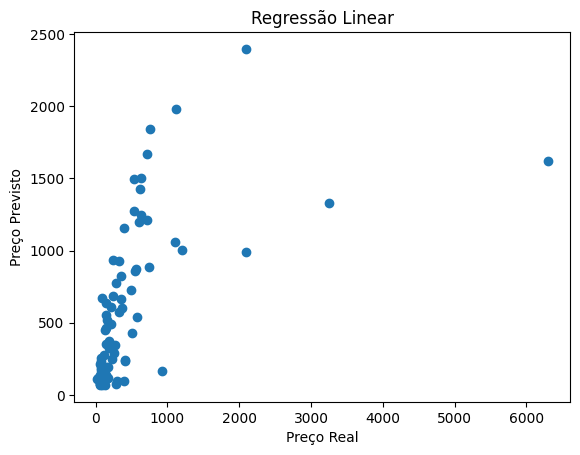

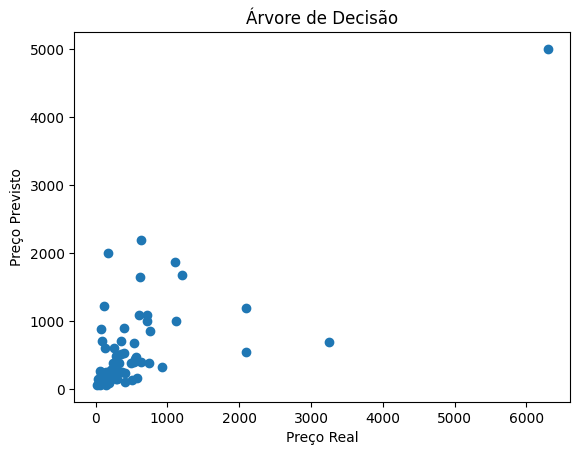

G3Dmark: 0.8615
TDP: 0.1385
Arquivo resultado_gpu.csv salvo no formato brasileiro!
      Preco_Real  Preco_Previsto
1481      296.76          154.00
386       184.00          135.99
208       362.00          254.91
1039       60.24          269.00
632       414.99          109.98


In [2]:
# ================================
# 1. IMPORTS
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ================================
# 2. CARREGAR DADOS
# ================================
df = pd.read_csv('GPU_benchmarks_v7.csv', encoding='latin1')

print(df.columns)
print(df.head())

# ================================
# 3. LIMPEZA
# ================================
# 1. Substitui textos de N/A por NaN do numpy
df = df.replace('N/A', np.nan)

# 2. Força a conversão para numérico PRIMEIRO (o que der erro vira NaN)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['G3Dmark'] = pd.to_numeric(df['G3Dmark'], errors='coerce')
df['TDP'] = pd.to_numeric(df['TDP'], errors='coerce')

# 3. Agora sim, remove qualquer linha que tenha ficado com NaN nessas colunas vitais
df = df.dropna(subset=['price', 'G3Dmark', 'TDP'])

# ================================
# 4. FEATURES
# ================================
features = ['G3Dmark', 'TDP']
target = 'price'

X = df[features]
y = df[target]

# ================================
# 5. TREINO / TESTE
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 6. MODELOS
# ================================
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# ================================
# 7. AVALIAÇÃO
# ================================
def avaliar(nome, y_test, y_pred):
    print(f"\n{nome}")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))

avaliar("Regressão Linear", y_test, y_pred_lr)
avaliar("Árvore de Decisão", y_test, y_pred_dt)

# ================================
# 8. GRÁFICOS
# ================================
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Preço Real")
plt.ylabel("Preço Previsto")
plt.title("Regressão Linear")
plt.show()

plt.figure()
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Preço Real")
plt.ylabel("Preço Previsto")
plt.title("Árvore de Decisão")
plt.show()

# ================================
# 9. IMPORTÂNCIA
# ================================
importancias = dt.feature_importances_

for i, f in enumerate(features):
    print(f"{f}: {importancias[i]:.4f}")





    resultado = pd.DataFrame({
    'Preco_Real': y_test,
    'Preco_Previsto': y_pred_dt
})

resultado.to_csv(
    'resultado_gpu.csv',
    index=False,
    sep=';',        # separa colunas com ponto e vírgula
    decimal=','     # usa vírgula como decimal
)

print("Arquivo resultado_gpu.csv salvo no formato brasileiro!")
print(resultado.head())